In [6]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [8]:
BATCH_SIZE = 32
IMG_SIZE = (224,224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "E:\datasets\PlantVillage",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "E:\datasets\PlantVillage",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [5]:
class_names = train_ds.class_names
print(class_names)
print(len(class_names))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
15


In [6]:
for X_batch, y_batch in train_ds.take(1):
    print(X_batch.shape)
    print(y_batch.shape)

(32, 224, 224, 3)
(32,)


In [7]:
AUTOTUNE= tf.data.AUTOTUNE
train_ds= train_ds.prefetch(AUTOTUNE)
val_ds= val_ds.prefetch(AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

In [9]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet')

In [11]:
NUM_CLASSES = 15

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',       # what to watch (val_loss or val_accuracy)
    patience=3,               # number of epochs with no improvement before stopping
    restore_best_weights=True # roll back to the best weights
)

checkpoint = ModelCheckpoint(
    filepath='ft5_model.keras', # file to save the best model
    monitor='val_loss',       # metric to monitor
    save_best_only=True,      # only save when val_loss improves
    verbose=1
)

In [24]:
base_model.trainable= False

In [25]:
inputs = tf.keras.Input(shape=(224,224,3))
x= data_augmentation(inputs)
x= preprocess_input(x)
x= base_model(x, training= False)
x= tf.keras.layers.GlobalAveragePooling2D()(x)
x= tf.keras.layers.Dropout(0.2)(x)
outputs= tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
model= tf.keras.Model(inputs, outputs)

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_3 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_3 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 15)                  │          19,215 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
    #callbacks=[checkpoint]
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 509s 987ms/step - accuracy: 0.8724 - loss: 0.3872 - val_accuracy: 0.8902 - val_loss: 0.3389
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - accuracy: 0.8857 - loss: 0.3491 - val_accuracy: 0.9089 - val_loss: 0.2909
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 605s 1s/step - accuracy: 0.8970 - loss: 0.3144 - val_accuracy: 0.9096 - val_loss: 0.2759
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 577s 1s/step - accuracy: 0.8998 - loss: 0.2987 - val_accuracy: 0.9087 - val_loss: 0.2669
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.9022 - loss: 0.2899 - val_accuracy: 0.9130 - val_loss: 0.2623
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 556s 1s/step - accuracy: 0.9073 - loss: 0.2753 - val_accuracy: 0.9147 - val_loss: 0.2549
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.9072 - loss: 0.2746 - val_accuracy: 0.9108 - val_loss: 0.2536
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 608s 1s/step - accuracy: 0.9097 - loss: 0.2633 - val_a

In [19]:
model.save("base_model.keras")

In [49]:
frozen_model = tf.keras.models.load_model("ft5_model.keras")

In [50]:
frozen_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 15)                  │          19,215 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,727,791 (18.04 MB)

 Trainable params: 1,225,295 (4.67 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,450,592 (9.35 MB)

In [51]:
base_model = frozen_model.get_layer("mobilenetv2_1.00_224")

In [52]:
base_model.trainable= True

In [35]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


In [53]:
for layer in base_model.layers[:134]: #training last 2 bottleneck blocks
    layer.trainable = False

In [54]:
print("Trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Trainable layers: 20


In [55]:
frozen_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"])

In [56]:
frozen_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 15)                  │          19,215 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 1,225,295 (4.67 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [57]:
history = frozen_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5, #to save time
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9252 - loss: 0.2147
Epoch 1: val_loss improved from 0.20843 to 0.19432, saving model to ft5_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.9262 - loss: 0.2114 - val_accuracy: 0.9343 - val_loss: 0.1943
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9321 - loss: 0.2023
Epoch 2: val_loss improved from 0.19432 to 0.17576, saving model to ft5_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - accuracy: 0.9334 - loss: 0.1957 - val_accuracy: 0.9402 - val_loss: 0.1758
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9392 - loss: 0.1795
Epoch 3: val_loss improved from 0.17576 to 0.16822, saving model to ft5_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 689s 1s/step - accuracy: 0.9391 - loss: 0.1774 - val_accuracy: 0.9433 - val_loss: 0.1682
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9439 - loss: 0.1656
Epoch 4: val_loss did not improve from 0.16822
516/516 ━━━

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
model = tf.keras.models.load_model("ft2_model.keras")

In [9]:
y_true= []
y_pred= []
for images, labels in val_ds:
    predictions= model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

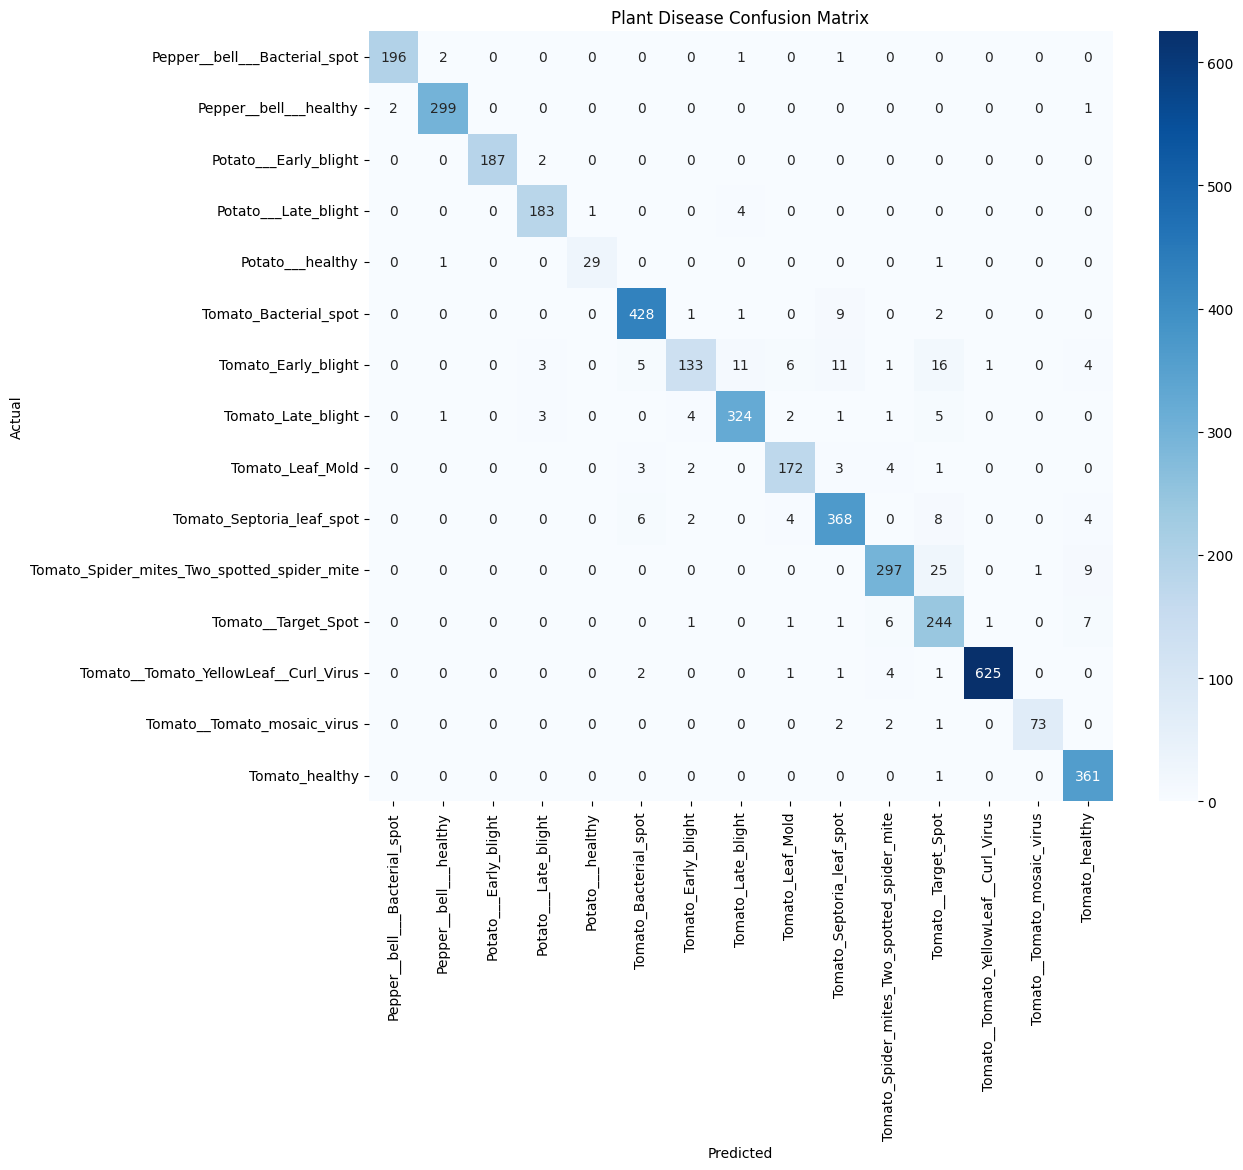

In [11]:
cm= confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels= train_ds.class_names,
            yticklabels= train_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Plant Disease Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.98      0.98       200
                     Pepper__bell___healthy       0.99      0.99      0.99       302
                      Potato___Early_blight       1.00      0.99      0.99       189
                       Potato___Late_blight       0.96      0.97      0.97       188
                           Potato___healthy       0.97      0.94      0.95        31
                      Tomato_Bacterial_spot       0.96      0.97      0.97       441
                        Tomato_Early_blight       0.93      0.70      0.80       191
                         Tomato_Late_blight       0.95      0.95      0.95       341
                           Tomato_Leaf_Mold       0.92      0.93      0.93       185
                  Tomato_Septoria_leaf_spot       0.93      0.94      0.93       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.89

In [16]:
model.evaluate(val_ds)

129/129 ━━━━━━━━━━━━━━━━━━━━ 109s 803ms/step - accuracy: 0.9496 - loss: 0.1504


[0.15039658546447754, 0.9496002197265625]